In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
import open3d as o3d
import copy

In [2]:
%matplotlib notebook

# Importing the calibration points from the vive
## position co-ordinates

In [6]:
vive_df = pd.read_csv('experiment_1_data/calibration1.csv', delimiter = '\t')
vive_data = np.array([eval(i) for i in vive_df['vive_reading'].values])
vive_data = vive_data[:,:3].T
vive_data = np.concatenate((vive_data, np.ones((1,max(vive_data.shape)))),axis = 0)

matprint(vive_data)

 0.542009  -0.575939  -1.31353   1.09881  0.352261  -0.393257   2.03411   1.30004  0.566113  
 -2.69277   -1.75515  -1.76237  -1.69707   -1.7198   -1.75523  -1.68948  -1.73879     -1.75  
-0.834165   -1.86973  -2.82595  -1.70498  -2.63927   -3.55339   -2.4271  -3.34083  -4.28908  
        1          1         1         1         1          1         1         1         1  


data is in the format of:<br>
x <br>
y <br>
z <br>
1 <br>

# Entering the room co-ordinates

In [7]:
# ref_data = np.array([
#     [3,    3.2,  0],
#     [3,    2,    0],
#     [3,    0.8,  0],
#     [1.8,  3.2,  0],
#     [1.8,  2,    0],
#     [1.8,  0.8,  0],
#     [0.6,  3.2,  0],
#     [0.6,  2,    0],
#     [0.6,  0.8,  0]
# ]).T
ref_data = np.array([
    [3,   0,  3.2],
    [3,   0,  2  ],
    [3,   0,  0.8],
    [1.8, 0,  3.2],
    [1.8, 0,  2, ],
    [1.8, 0,  0.8],
    [0.6, 0,  3.2],
    [0.6, 0,  2, ],
    [0.6, 0,  0.8]
]).T
ref_data = np.concatenate((ref_data, np.ones((1,max(ref_data.shape)))),axis = 0)
matprint(ref_data)

  3  3    3  1.8  1.8  1.8  0.6  0.6  0.6  
  0  0    0    0    0    0    0    0    0  
3.2  2  0.8  3.2    2  0.8  3.2    2  0.8  
  1  1    1    1    1    1    1    1    1  


### Pull reference points to origin

In [8]:
zero_basis_vector = 8  # the vector pointing to the "new" zero O'
x_basis_vector = 2     # vector formed between here and 0' will only have an x component
y_basis_vector = 6     # vector formed between heere and 0' will only have a z component


# the first step is to move our points so that 0' (our corner) is actually at [0,0,0]. This makes the rotations simpler
zero_translation = trans_mat(np.identity(4), -ref_data[:,zero_basis_vector]) # find matrix to do the translation
gt = zero_translation.dot(ref_data) # apply the translation to all reference points
matprint(gt)

2.4  2.4  2.4  1.2  1.2  1.2    0    0  0  
  0    0    0    0    0    0    0    0  0  
2.4  1.2    0  2.4  1.2    0  2.4  1.2  0  
  1    1    1    1    1    1    1    1  1  


Note that the last point is the zero points, this is just how the data ended up being collected

### Pull vive points to origin

In [9]:
tr = gt[:,zero_basis_vector] - vive_data[:,zero_basis_vector] # find translation vector from vive origin to [0,0,0]
translation_matrix = trans_mat(np.identity(4), tr) # find translation matrix from vector
vi = translation_matrix.dot(vive_data)             # apply translation to vive points
matprint(vi)

-0.024105     -1.14205   -1.87964   0.532698  -0.213853  -0.959371      1.468   0.733929  0  
-0.942777  -0.00515223  -0.012372  0.0529313   0.030201  -0.005229  0.0605214  0.0112106  0  
  3.45491      2.41935    1.46313     2.5841    1.64981   0.735686    1.86198   0.948245  0  
        1            1          1          1          1          1          1          1  1  


Both sets of points now have the last entry (entry 9) at the origin. The next step is to align the points

### Visual check

<IPython.core.display.Javascript object>


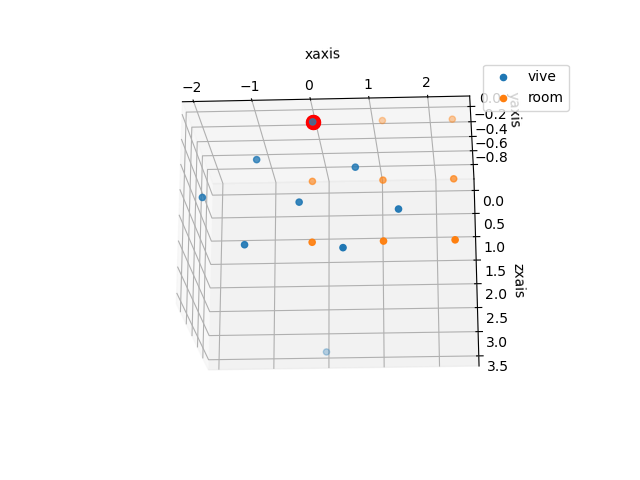

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(vi[0], vi[1], vi[2],label = 'vive')
ax.scatter(gt[0], gt[1], gt[2], label = 'room')

ax.scatter(vi[0][8], vi[1][8],vi[2][8],s=100, c= 'r')
ax.scatter(gt[0][8], gt[1][8],gt[2][8],s=100, c = 'r')
ax.set_xlabel('xaxis'); ax.set_ylabel('yaxis'); ax.set_zlabel('zxais')
ax.legend()
ax.view_init(elev=120., azim=-90)
# ax.axis('off')

There is obviously one outlying point that needs to be reomved. 

In [11]:
vive_color = '#2471A3'
room_color = '#F1C40F'

<IPython.core.display.Javascript object>


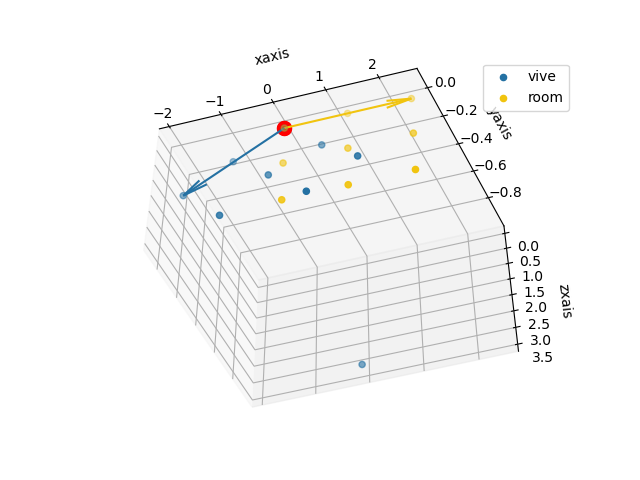

In [12]:
def plot_x_basis():  
    fig = plt.figure()
    ax = fig.add_subplot(111, projection = '3d')
    ax.scatter(vi[0], vi[1], vi[2],label = 'vive', color = vive_color)  # plot all vive points
    ax.scatter(gt[0], gt[1], gt[2], label = 'room', color = room_color) # plot all room points

    ax.scatter(vi[0][8], vi[1][8],vi[2][8],s=100, c= 'r') # zero point on vive data
    ax.scatter(gt[0][8], gt[1][8],gt[2][8],s=100, c = 'r') # zero point of room data

    ax.quiver(0,0,0,vi[0][x_basis_vector], vi[1][x_basis_vector],vi[2][x_basis_vector],arrow_length_ratio = 0.2, color = vive_color)  # 
    ax.quiver(0,0,0,gt[0][x_basis_vector], gt[1][x_basis_vector],gt[2][x_basis_vector],arrow_length_ratio = 0.2, color = room_color)  # 


    ax.set_xlabel('xaxis'); ax.set_ylabel('yaxis'); ax.set_zlabel('zxais')
    ax.legend()
    ax.view_init(elev=120., azim=-90)
    #ax.axis('off')
    
plot_x_basis()

### Alignment of x axis
Aligning the x axis requires two steps <br>
- firstly a rotation about the x axis untill the vive unit vector is on the x-y plane<br>
- Followed by a rotation about the z axis untill the x unit vectors are co-linear

### Rotation about x axis

In [13]:
vi = translation_matrix.dot(vive_data) # ensure we are dealing with translated data
gt_x = gt[:,x_basis_vector]   # vector only has an x component
vi_x = vi[:,x_basis_vector]

# By taking the cross product, we can get a new vecor in the y-z plane that has the angle
# from the unit y vector that we need to rotate the vive x-basis into the x-y plane
cross_x = np.cross(gt_x[:3].T, vi_x[:3].T)  # find cross product
x_ang = np.arctan2(cross_x[1],cross_x[2])   # find required angle

x_rotation_matrix = rot_x(np.identity(4),x_ang) # create the rotation matrix b
vi = x_rotation_matrix.dot(translation_matrix.dot(vive_data))  #apply translation and rotation to data

<IPython.core.display.Javascript object>


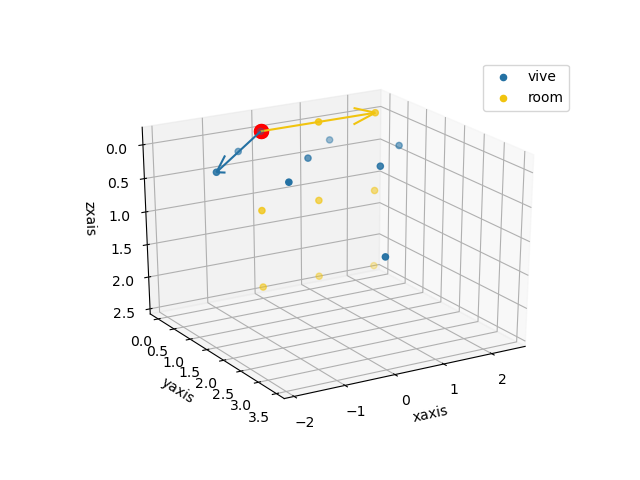

In [14]:
plot_x_basis()


### Rotation about z axis

<IPython.core.display.Javascript object>


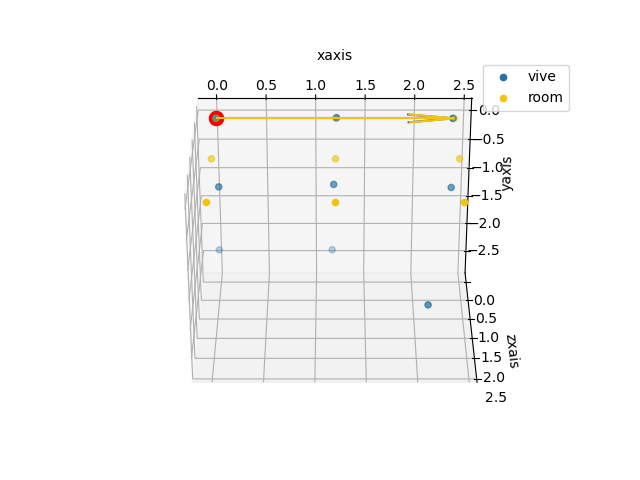

In [15]:
vi = x_rotation_matrix.dot(translation_matrix.dot(vive_data))  #ensure translation is upto date
z_ang = np.arctan2(vi[1,x_basis_vector] , vi[0,x_basis_vector]) # calculate angle to rotate
z_rotation_matrix = rot_z(np.identity(4), -z_ang)
vi = z_rotation_matrix.dot(vi)

plot_x_basis()

### Alignment of y basis vectors

<IPython.core.display.Javascript object>


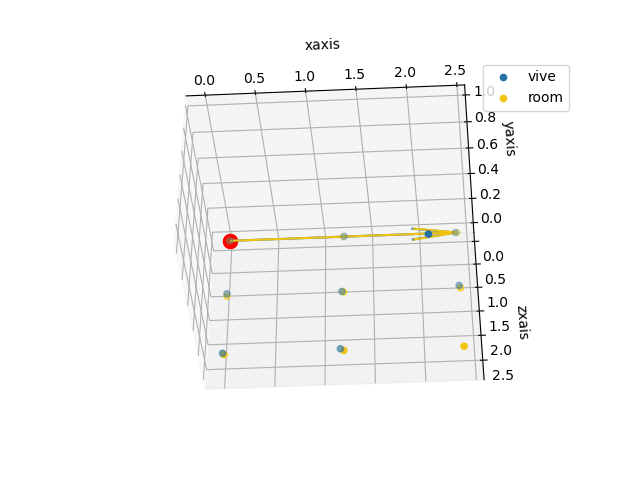

In [16]:
vi = z_rotation_matrix.dot(x_rotation_matrix.dot(translation_matrix.dot(vive_data)))
gt_y = gt[:,y_basis_vector]
vi_y = vi[:,y_basis_vector]
x_ang = np.arctan2(vi[1,y_basis_vector] , vi[2,y_basis_vector])
x_rotation_matrix_2 = rot_x(np.identity(4), x_ang)
vi = x_rotation_matrix_2.dot(vi)
plot_x_basis()

### Send origin back to original position


<IPython.core.display.Javascript object>


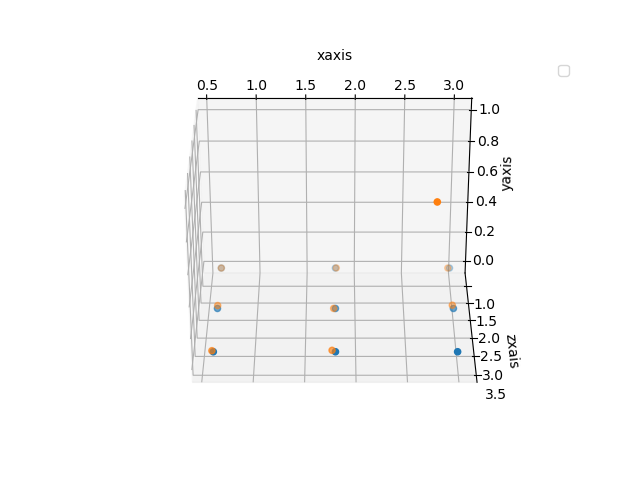

No handles with labels found to put in legend.


In [17]:
vi = x_rotation_matrix_2.dot(z_rotation_matrix.dot(x_rotation_matrix.dot(translation_matrix.dot(vive_data))))
inv_zero =  np.linalg.inv(zero_translation)
translation_matrix_2 = inv_zero.dot(np.identity(4))

vi = translation_matrix_2.dot(vi)


fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(ref_data[0], ref_data[1], ref_data[2])
ax.scatter(vi[0], vi[1], vi[2])

ax.set_xlabel('xaxis'); ax.set_ylabel('yaxis'); ax.set_zlabel('zxais')
ax.legend()
ax.view_init(elev=120., azim=-90)

# Using ICP to finalize translation matrix

In [22]:
source

array([[-0.5759393 , -1.75514889, -1.86973298],
       [-1.31352782, -1.76236868, -2.82594991],
       [ 1.09881175, -1.69706535, -1.70497942],
       [ 0.35226089, -1.7197957 , -2.63926601],
       [-0.3932575 , -1.75522566, -3.55339217],
       [ 2.03411317, -1.6894753 , -2.42709851],
       [ 1.30004227, -1.7387861 , -3.34083319],
       [ 0.56611347, -1.74999666, -4.28907824]])

In [18]:
# link all rotations and translations together
initial_transform = translation_matrix_2.dot(x_rotation_matrix_2.dot(z_rotation_matrix.dot(x_rotation_matrix.dot(translation_matrix.dot(np.identity(4))))))


# remove the  outlying point
raw_vive = vive_data[:,1:]
raw_ref = ref_data[:,1:]
# convert data into format that open3D can use
source = raw_vive[:3,:].T 
target = raw_ref[:3,:].T

# create the pointclouds
ref_pcd = o3d.geometry.PointCloud()
ref_pcd.points = o3d.utility.Vector3dVector(target)

vive_pcd = o3d.geometry.PointCloud()
vive_pcd.points = o3d.utility.Vector3dVector(source)

# perform the ICP and obtain the resulting matrix
threshold = 0.02
reg_p2p = o3d.registration.registration_icp(vive_pcd, ref_pcd, threshold, initial_transform,o3d.registration.TransformationEstimationPointToPoint())
best_transform = reg_p2p.transformation


In [19]:
print(initial_transform)
print(best_transform)

[[-0.7891004  -0.00519395  0.61424228  3.67216416]
 [ 0.01975117 -0.99966173  0.01692079 -1.68801149]
 [ 0.61394661  0.02548421  0.78893606  3.88084233]
 [ 0.          0.          0.          1.        ]]
[[-7.88046591e-01 -6.02967988e-03  6.15586073e-01  3.67875561e+00]
 [ 9.29258165e-03 -9.99954615e-01  2.10138132e-03 -1.74477791e+00]
 [ 6.15545464e-01  7.37637023e-03  7.88066857e-01  3.84694966e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


# Final check of translation

<IPython.core.display.Javascript object>


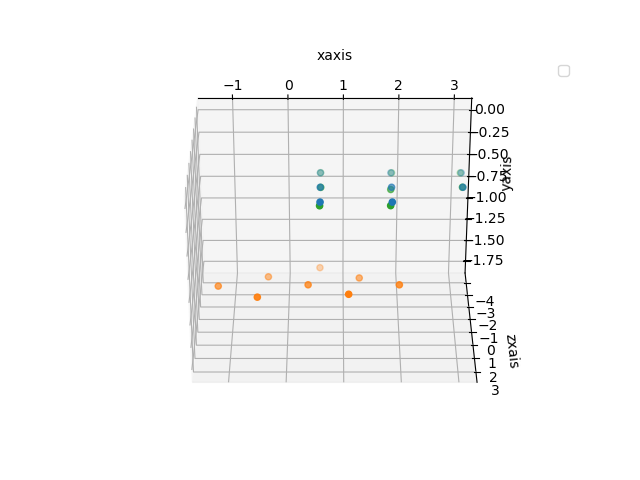

No handles with labels found to put in legend.


In [20]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(raw_ref[0], raw_ref[1], raw_ref[2])
ax.scatter(raw_vive[0], raw_vive[1], raw_vive[2])

output = best_transform.dot(raw_vive)
ax.scatter(output[0], output[1], output[2])

ax.set_xlabel('xaxis'); ax.set_ylabel('yaxis'); ax.set_zlabel('zxais')
ax.legend()
ax.view_init(elev=120., azim=-90)

In [ ]:
# function to translate the origin by vec
def trans_mat(mat, vec):    
    dx = vec[0]
    dy = vec[1]
    dz = vec[2]
    trans_mat=np.array([
        [1,0,0,dx],
        [0,1,0,dy],
        [0,0,1,dz],
        [0,0,0,1]
    ])
    return trans_mat.dot(mat)



def find_dot_ang(v1, v2):
    dot = np.dot(v1[:3], v2[:3])
    mag = np.linalg.norm(v1[:3]) * np.linalg.norm(v2[:3])
    ang = np.arccos(dot/mag)
    return ang

def rot_x(mat, ang):

    rot_mat = np.array([
        [1,          0,             0,            0],
        [0,          np.cos(ang),  -np.sin(ang),  0],
        [0,          np.sin(ang),   np.cos(ang),  0],
        [0,          0,             0,            1]
    ])
    return rot_mat.dot(mat)

def rot_y(mat,ang):
    
    rot_mat = np.array([
        [np.cos(ang) , 0, np.sin(ang), 0],
        [0,            1,    0,        0],
        [-np.sin(ang), 0, np.cos(ang), 0],
        [0,            0,      0,      1]
    ])
    return rot_mat.dot(mat)


    
    
def rot_z(mat, ang):
    rot_mat = np.array([
        [np.cos(ang), -np.sin(ang), 0,  0],
        [np.sin(ang), np.cos(ang),  0,  0],
        [0,             0,          1,  0],
        [0,             0,          0,  1]
    ])
    
    return rot_mat.dot(mat)


def rmse(mat1, mat2):
    res = mat1 - mat2
    res = np.square(res)
    res = np.sum(res)
    res = res/max(mat1.shape)
    res = np.sqrt(res)
    return res


def draw_registration_result(source, target, transformation):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    source_temp.paint_uniform_color([1, 0.706, 0])
    target_temp.paint_uniform_color([0, 0.651, 0.929])
    source_temp.transform(transformation)
    o3d.visualization.draw_geometries([source_temp, target_temp])    

def matprint(mat, fmt="g"):
    col_maxes = [max([len(("{:"+fmt+"}").format(x)) for x in col]) for col in mat.T]
    for x in mat:
        for i, y in enumerate(x):
            print(("{:"+str(col_maxes[i])+fmt+"}").format(y), end="  ")
        print("")

In [5]:
def matprint(mat, fmt="g"):
    col_maxes = [max([len(("{:"+fmt+"}").format(x)) for x in col]) for col in mat.T]
    for x in mat:
        for i, y in enumerate(x):
            print(("{:"+str(col_maxes[i])+fmt+"}").format(y), end="  ")
        print("")